downloads IBTrACS once
keeps all CONUS storms (or at least all storms in your dataset)
computes:
min_dist_to_storm_km
(optionally ready for) storm_max_wind, translation_speed
builds RF_v2
compares:
with / without CountyFIPS
produces:
scatter plots (incl. storm-coloured)

In [2]:
2+2


4

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

from shapely.geometry import Point
from geopy.distance import geodesic

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [4]:
event_df = pd.read_csv(
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_clean.csv"
)

event_df["CountyFIPS"] = event_df["CountyFIPS"].astype(str).str.zfill(5)

print(event_df.shape)
print(event_df.head())

(90, 11)
                            event_id          storm CountyFIPS         t90  \
0  2017212N28275_2017-07-30 21:00:00  2017212N28275      12075    1.885185   
1  2017242N16333_2017-09-09 19:00:00  2017242N16333      12037  120.406155   
2  2017242N16333_2017-09-09 20:00:00  2017242N16333      12067  186.802564   
3  2017242N16333_2017-09-09 21:00:00  2017242N16333      12013   52.651220   
4  2017242N16333_2017-09-09 22:00:00  2017242N16333      12075  170.764203   

   t90_censored   max_gust  mean_gust_7d  total_precip_7d  pressure_min_7d  \
0             0  12.601287      7.421799        67.413998      1009.864246   
1             0  27.279316     12.005697        92.750718       995.318712   
2             0  33.241034      9.333728       153.916280       982.833530   
3             0  25.291777     14.104932        89.230104       996.010565   
4             0  33.169058      9.553964       145.733609       976.919507   

   max_customers_tracked  county_pop  
0             

In [5]:
# -----------------------
# Load IBTrACS
# -----------------------
ib = pd.read_csv(
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\ibtracs_conus_subset.csv",
    low_memory=False
)

# -----------------------
# Clean
# -----------------------
ib["ISO_TIME"] = pd.to_datetime(ib["ISO_TIME"], errors="coerce")
ib = ib.dropna(subset=["ISO_TIME"])

# Rename columns
ib = ib.rename(columns={
    "SID": "storm_id_ib",
    "LAT": "lat",
    "LON": "lon",
    "USA_WIND": "wind_knots"
})

# Convert wind to numeric
ib["wind_knots"] = pd.to_numeric(ib["wind_knots"], errors="coerce")

# Convert to m/s (wind not required for distance, but keep for later)
ib["wind_mps"] = ib["wind_knots"] * 0.514444

# Extract year
ib["year"] = ib["ISO_TIME"].dt.year

print("IBTrACS rows:", len(ib))
print("Unique storms:", ib["storm_id_ib"].nunique())
print(ib.head())

C:\Users\teaching\AppData\Local\Temp\ipykernel_30424\690637262.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ib["ISO_TIME"] = pd.to_datetime(ib["ISO_TIME"], errors="coerce")


IBTrACS rows: 716165
Unique storms: 13811
     storm_id_ib SEASON NUMBER BASIN SUBBASIN       NAME            ISO_TIME  \
1  1842298N11080   1842      1    NI       BB  NOT_NAMED 1842-10-25 03:00:00   
2  1842298N11080   1842      1    NI       BB  NOT_NAMED 1842-10-25 06:00:00   
3  1842298N11080   1842      1    NI       BB  NOT_NAMED 1842-10-25 09:00:00   
4  1842298N11080   1842      1    NI       BB  NOT_NAMED 1842-10-25 12:00:00   
5  1842298N11080   1842      1    NI       BB  NOT_NAMED 1842-10-25 15:00:00   

  NATURE      lat      lon  ... REUNION_GUST_PER USA_SEAHGT USA_SEARAD_NE  \
1     NR  10.9000  80.3000  ...                                             
2     NR  10.8709  79.8265  ...                                             
3     NR  10.8431  79.3524  ...                                             
4     NR  10.8188  78.8772  ...                                             
5     NR  10.8000  78.4000  ...                                             

  USA_SEARAD_S

the *ibtracs_conus_subset.csv* file has Ian as a different stormID (2022266N12294) when compared to the *POUS.csv* (2022263N10313). This is likely due to differences in how the two datasets identify storms. The *ibtracs_conus_subset.csv* may be using a different naming convention or source for storm identification, which can lead to discrepancies when merging or comparing the datasets. To resolve this, you may need to standardize the storm IDs across both datasets before performing any analysis or merging operations.

So, I'll do my own filtering of ibtracs.

In [6]:
import pandas as pd
import numpy as np

event_df = pd.read_csv(
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_clean.csv"
)

event_df["CountyFIPS"] = event_df["CountyFIPS"].astype(str).str.zfill(5)

print("Event DF shape:", event_df.shape)
print("Unique storms:", event_df["storm"].nunique())
print(event_df["storm"].unique())

Event DF shape: (90, 11)
Unique storms: 7
<ArrowStringArray>
['2017212N28275', '2017242N16333', '2018280N18273', '2020256N25281',
 '2021182N09317', '2021222N14301', '2022263N10313']
Length: 7, dtype: str


In [7]:
ib = pd.read_csv(
    r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\ibtracs_conus_subset.csv",
    low_memory=False
)

# Keep relevant columns
ib = ib[["SID", "ISO_TIME", "LAT", "LON", "USA_WIND"]].copy()

# Clean time
ib["ISO_TIME"] = pd.to_datetime(ib["ISO_TIME"], errors="coerce")
ib = ib.dropna(subset=["ISO_TIME"])

# Rename
ib = ib.rename(columns={
    "SID": "storm_id_ib",
    "LAT": "lat",
    "LON": "lon",
    "USA_WIND": "wind_knots"
})

# Convert wind (optional)
ib["wind_knots"] = pd.to_numeric(ib["wind_knots"], errors="coerce")

print("IBTrACS rows:", len(ib))
print("IBTrACS storms:", ib["storm_id_ib"].nunique())

C:\Users\teaching\AppData\Local\Temp\ipykernel_30424\2968885555.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ib["ISO_TIME"] = pd.to_datetime(ib["ISO_TIME"], errors="coerce")


IBTrACS rows: 716165
IBTrACS storms: 13811


In [8]:
# Extract years
event_df["year"] = event_df["storm"].str[:4].astype(int)
ib["year"] = ib["ISO_TIME"].dt.year

# Filter IBTrACS to relevant years
ib = ib[ib["year"].isin(event_df["year"].unique())]

print("IBTrACS storms after year filter:", ib["storm_id_ib"].nunique())
print("Years in IBTrACS:", sorted(ib["year"].unique()))
print("Years in events:", sorted(event_df["year"].unique()))

IBTrACS storms after year filter: 559
Years in IBTrACS: [np.int32(2017), np.int32(2018), np.int32(2020), np.int32(2021), np.int32(2022)]
Years in events: [np.int64(2017), np.int64(2018), np.int64(2020), np.int64(2021), np.int64(2022)]


In [9]:
import geopandas as gpd

url = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
counties = gpd.read_file(url)
counties = counties.rename(columns={"id": "CountyFIPS"})

counties["CountyFIPS"] = counties["CountyFIPS"].astype(str)

# Florida only
counties = counties[counties["CountyFIPS"].str.startswith("12")].copy()

# Centroids
counties["centroid"] = counties.geometry.centroid

print("Florida counties:", len(counties))

Florida counties: 67


C:\Users\teaching\AppData\Local\Temp\ipykernel_30424\4210375854.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  counties["centroid"] = counties.geometry.centroid


In [10]:
from geopy.distance import geodesic

distances = []
missing_cases = []

for idx, row in event_df.iterrows():
    storm_year = row["year"]
    county = row["CountyFIPS"]

    # Get centroid
    match = counties[counties["CountyFIPS"] == county]
    
    if len(match) == 0:
        distances.append(np.nan)
        missing_cases.append(("county_missing", county))
        continue

    centroid = match["centroid"].iloc[0]
    county_latlon = (centroid.y, centroid.x)

    # Get ALL storm tracks for that year
    track = ib[ib["year"] == storm_year]

    if len(track) == 0:
        distances.append(np.nan)
        missing_cases.append(("no_track_for_year", storm_year))
        continue

    # Compute distances
    dists = [
        geodesic(county_latlon, (r["lat"], r["lon"])).km
        for _, r in track.iterrows()
    ]

    distances.append(min(dists))

event_df["min_dist_to_storm_km"] = distances

In [11]:
print("Distance summary:")
print(event_df["min_dist_to_storm_km"].describe())

print("\nNumber of NaNs:", event_df["min_dist_to_storm_km"].isna().sum())

print("\nExample NaN rows:")
print(event_df[event_df["min_dist_to_storm_km"].isna()][["CountyFIPS", "storm", "year"]].head())

print("\nMissing cases log:")
print(missing_cases[:10])

Distance summary:
count     90.000000
mean      57.645530
std       39.941977
min        6.319750
25%       27.896647
50%       45.444157
75%       84.677646
max      169.092475
Name: min_dist_to_storm_km, dtype: float64

Number of NaNs: 0

Example NaN rows:
Empty DataFrame
Columns: [CountyFIPS, storm, year]
Index: []

Missing cases log:
[]


Right now you are using:

distance to any storm track in that year

This was a debugging step, not the final feature.

Now, we find the distance to the correct storm track for that event.
--
For each (event, county):

Get event_start

Find IBTrACS tracks where:

|track_time - event_start| < X hours (e.g. 48h)
Compute distance using only those tracks

In [12]:
from geopy.distance import geodesic

distances = []
storm_match_ids = []

event_df["event_start"] = pd.to_datetime(
    event_df["event_id"].str.split("_").str[1]
)

for idx, row in event_df.iterrows():
    event_time = pd.to_datetime(row["event_start"])
    county = row["CountyFIPS"]

    # County centroid
    match = counties[counties["CountyFIPS"] == county]
    centroid = match["centroid"].iloc[0]
    county_latlon = (centroid.y, centroid.x)

    # Find storms near this time (±48h window)
    window = ib[
        (ib["ISO_TIME"] >= event_time - pd.Timedelta(hours=48)) &
        (ib["ISO_TIME"] <= event_time + pd.Timedelta(hours=48))
    ]

    if len(window) == 0:
        distances.append(np.nan)
        storm_match_ids.append(None)
        continue

    # Compute distances
    dists = []
    storm_ids = []

    for _, r in window.iterrows():
        d = geodesic(county_latlon, (r["lat"], r["lon"])).km
        dists.append(d)
        storm_ids.append(r["storm_id_ib"])

    # Minimum distance
    min_idx = np.argmin(dists)

    distances.append(dists[min_idx])
    storm_match_ids.append(storm_ids[min_idx])

event_df["min_dist_to_storm_km"] = distances
event_df["matched_ibtracs_storm"] = storm_match_ids

In [13]:
print("Unique matched IBTrACS storms:")
print(event_df["matched_ibtracs_storm"].nunique())

print("\nCounts:")
print(event_df["matched_ibtracs_storm"].value_counts())

Unique matched IBTrACS storms:
7

Counts:
matched_ibtracs_storm
2017242N16333    49
2022266N12294    19
2018280N18273    14
2020256N25281     3
2021222N14301     3
2017212N28275     1
2021182N09317     1
Name: count, dtype: int64


nice, 7 now. 

but “Which storms got filtered out earlier?” Take a look at the bottom of the filtering_of script to asnwer that q.

Now onto the actual RF stuff:

In [14]:
features = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop",
    "min_dist_to_storm_km",
    # "storm_max_wind_mps" let's add this eventually
]

X_nc = event_df[features]
y = event_df["t90"]
groups = event_df["storm"]

🔧 Step 3 — RF (no CountyFIPS)

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error

pre_nc = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features)
])

rf_nc = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=3,
    random_state=42
)

model_nc = Pipeline([
    ("pre", pre_nc),
    ("rf", rf_nc)
])


🔧 Step 4 — RF (with CountyFIPS)

In [16]:
X_wc = event_df[features + ["CountyFIPS"]]

from sklearn.preprocessing import OneHotEncoder

pre_wc = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["CountyFIPS"])
])

rf_wc = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=3,
    random_state=42
)

model_wc = Pipeline([
    ("pre", pre_wc),
    ("rf", rf_wc)
])

🔧 Step 5 — CV evaluation

In [17]:
logo = LeaveOneGroupOut()

def run_model(model, X, y, groups):
    preds = np.full(len(X), np.nan)

    for train, test in logo.split(X, y, groups):
        model.fit(X.iloc[train], y.iloc[train])
        preds[test] = model.predict(X.iloc[test])

    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))

    return preds, mae, rmse

pred_nc, mae_nc, rmse_nc = run_model(model_nc, X_nc, y, groups)
pred_wc, mae_wc, rmse_wc = run_model(model_wc, X_wc, y, groups)

print("RF_v2 (no county): MAE =", mae_nc, "RMSE =", rmse_nc)
print("RF_v2 (with county): MAE =", mae_wc, "RMSE =", rmse_wc)

RF_v2 (no county): MAE = 120.04072406370459 RMSE = 147.2135637737604
RF_v2 (with county): MAE = 120.08670418655598 RMSE = 147.4987088537169


🔧 Step 6 — Scatter plots (storm-coloured)

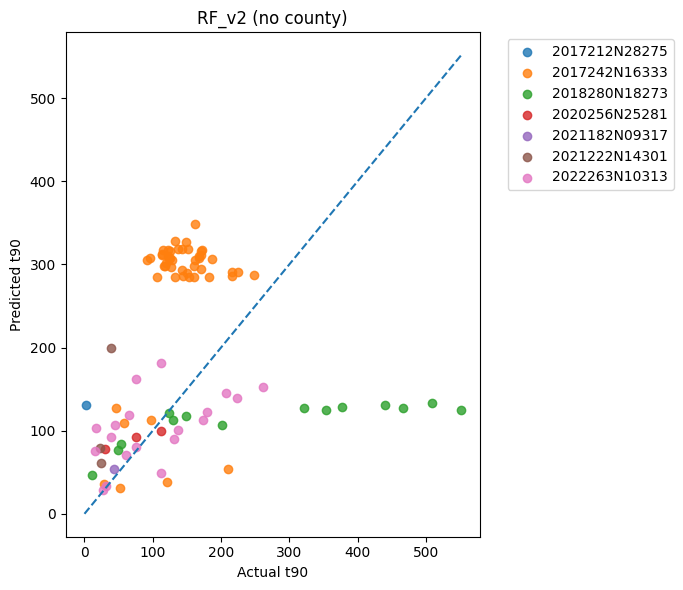

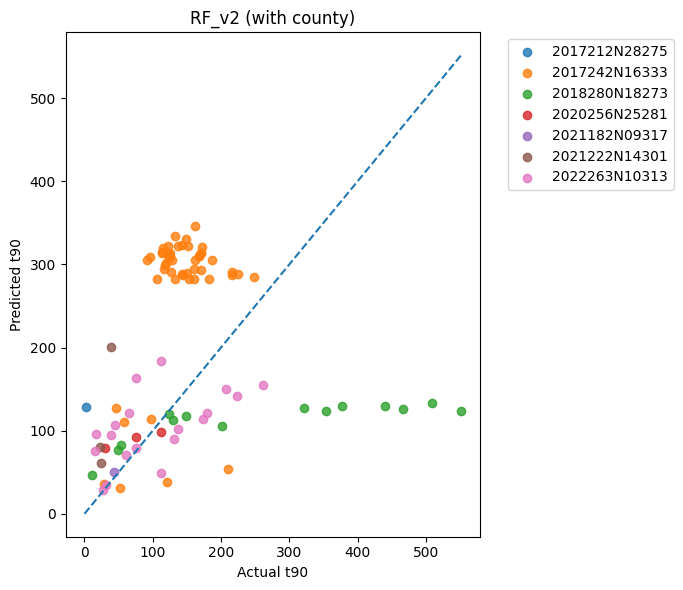

In [18]:
import matplotlib.pyplot as plt

def plot_scatter(preds, title):
    plt.figure(figsize=(7,6))

    for storm in event_df["storm"].unique():
        s = event_df["storm"] == storm
        plt.scatter(event_df["t90"][s], preds[s], label=storm, alpha=0.8)

    m = event_df["t90"].max()
    plt.plot([0, m], [0, m], "--")

    plt.xlabel("Actual t90")
    plt.ylabel("Predicted t90")
    plt.title(title)

    plt.legend(bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

plot_scatter(pred_nc, "RF_v2 (no county)")
plot_scatter(pred_wc, "RF_v2 (with county)")

🔧 Step 7 — Feature importance (key diagnostic)

pressure_min_7d         0.315591
max_gust                0.240167
mean_gust_7d            0.223262
total_precip_7d         0.128916
min_dist_to_storm_km    0.076668
county_pop              0.015396
dtype: float64


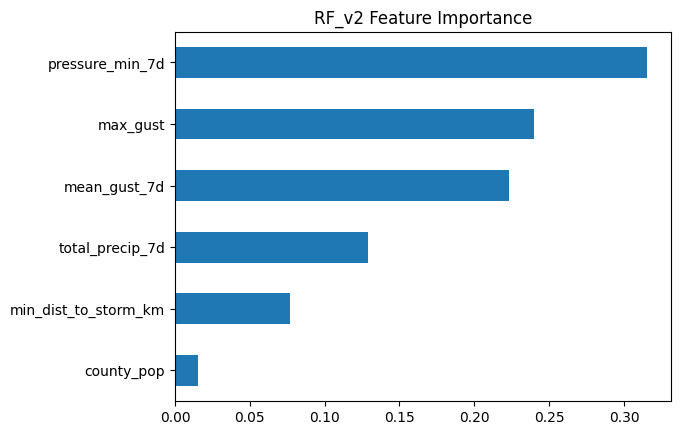

In [19]:
rf_model = model_nc.named_steps["rf"]

importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

print(feat_imp)

feat_imp.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("RF_v2 Feature Importance")
plt.show()

pressure_min_7d         0.320164
max_gust                0.222650
mean_gust_7d            0.220635
total_precip_7d         0.141227
min_dist_to_storm_km    0.080185
county_pop              0.015048
CountyFIPS_12037        0.000091
CountyFIPS_12003        0.000000
CountyFIPS_12001        0.000000
CountyFIPS_12007        0.000000
CountyFIPS_12011        0.000000
CountyFIPS_12013        0.000000
CountyFIPS_12015        0.000000
CountyFIPS_12017        0.000000
CountyFIPS_12019        0.000000
CountyFIPS_12021        0.000000
CountyFIPS_12005        0.000000
CountyFIPS_12023        0.000000
CountyFIPS_12029        0.000000
CountyFIPS_12033        0.000000
dtype: float64


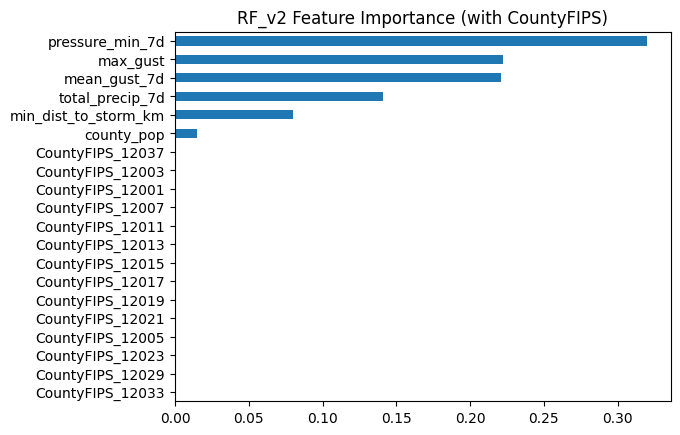

Total CountyFIPS importance: 9.124347470785262e-05


In [20]:
# same but with countyfips:
# Get trained RF model
rf_model = model_wc.named_steps["rf"]

# Get preprocessor
pre = model_wc.named_steps["pre"]

# Extract feature names
num_features = features
cat_features = pre.named_transformers_["cat"].get_feature_names_out(["CountyFIPS"])

all_feature_names = list(num_features) + list(cat_features)

# Get importances
importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

print(feat_imp.head(20))

# Plot top features only (important, otherwise too crowded)
feat_imp.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("RF_v2 Feature Importance (with CountyFIPS)")
plt.show()

county_importance = feat_imp[feat_imp.index.str.startswith("CountyFIPS")].sum()

print("Total CountyFIPS importance:", county_importance)


Some plots just for fun:

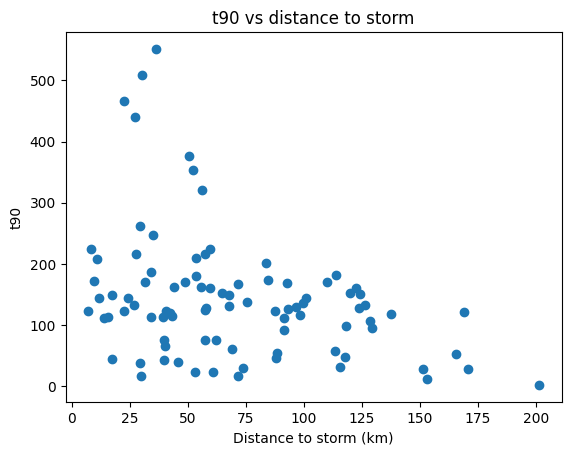

In [21]:
plt.scatter(event_df["min_dist_to_storm_km"], event_df["t90"])
plt.xlabel("Distance to storm (km)")
plt.ylabel("t90")
plt.title("t90 vs distance to storm")
plt.show()

^ a bit of a negative correlation, as expected.

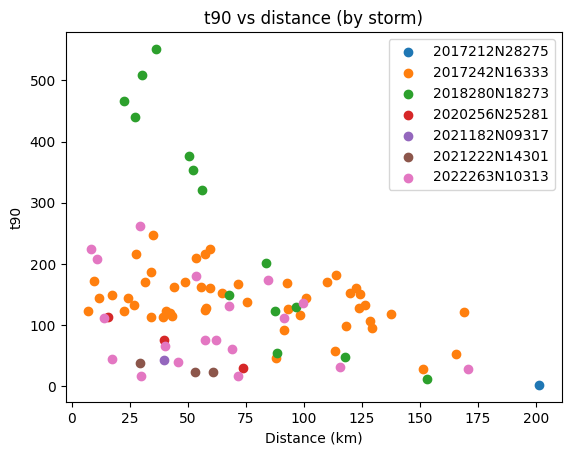

In [22]:
for storm in event_df["storm"].unique():
    s = event_df["storm"] == storm
    plt.scatter(event_df["min_dist_to_storm_km"][s],
                event_df["t90"][s],
                label=storm)

plt.legend()
plt.xlabel("Distance (km)")
plt.ylabel("t90")
plt.title("t90 vs distance (by storm)")
plt.show()

Correlations:

In [23]:
from scipy.stats import pearsonr, spearmanr

# -----------------------
# Overall correlation
# -----------------------
pearson_corr, pearson_p = pearsonr(
    event_df["min_dist_to_storm_km"],
    event_df["t90"]
)

spearman_corr, spearman_p = spearmanr(
    event_df["min_dist_to_storm_km"],
    event_df["t90"]
)

print("Overall correlation:")
print(f"Pearson r = {pearson_corr:.3f} (p={pearson_p:.3e})")
print(f"Spearman ρ = {spearman_corr:.3f} (p={spearman_p:.3e})")

Overall correlation:
Pearson r = -0.354 (p=6.108e-04)
Spearman ρ = -0.318 (p=2.233e-03)


In [24]:
print("\nPer-storm correlations:")

results = []

for storm in event_df["storm"].unique():
    subset = event_df[event_df["storm"] == storm]
    
    if len(subset) < 3:
        continue  # skip tiny groups
    
    try:
        p_corr, _ = pearsonr(subset["min_dist_to_storm_km"], subset["t90"])
        s_corr, _ = spearmanr(subset["min_dist_to_storm_km"], subset["t90"])
        
        results.append({
            "storm": storm,
            "n": len(subset),
            "pearson": p_corr,
            "spearman": s_corr
        })
        
    except:
        continue

corr_df = pd.DataFrame(results).sort_values("pearson", ascending=False)

print(corr_df)


Per-storm correlations:
           storm   n   pearson  spearman
4  2022263N10313  19 -0.370104 -0.371930
0  2017242N16333  49 -0.434070 -0.340000
1  2018280N18273  14 -0.913685 -0.942857
3  2021222N14301   3 -0.965199 -0.500000
2  2020256N25281   3 -0.999212 -1.000000


In [25]:
import seaborn as sns

sns.regplot(
    x="min_dist_to_storm_km",
    y="t90",
    data=event_df,
    scatter_kws={"alpha": 0.6}
)

plt.title("t90 vs distance (global trend)")
plt.show()

ModuleNotFoundError: No module named 'seaborn'